# Tarea

Es un problema de regresión: tenéis que predecir el precio del Airbnb utilizando los datos disponibles.

In [1]:
import numpy  as np  
import pandas as pd

import matplotlib.pyplot as plt
%matplotlib inline

import warnings
warnings.filterwarnings('ignore')

Vamos a cargar el csv de Airbnb

In [2]:
house_data = pd.read_csv("./practica/airbnb-listings-extract.csv", sep=";") # cargamos fichero
print(house_data.shape)
house_data.head(5).T 

(14780, 89)


,0,1,2,3,4
ID,11210388,17471131,17584891,5398030,18104606
Listing Url,https://www.airbnb.com/rooms/11210388,https://www.airbnb.com/rooms/17471131,https://www.airbnb.com/rooms/17584891,https://www.airbnb.com/rooms/5398030,https://www.airbnb.com/rooms/18104606
Scrape ID,20170306202425,20170407214050,20170407214050,20170407214050,20170407214050
Last Scraped,2017-03-07,2017-04-08,2017-04-08,2017-04-08,2017-04-08
Name,The Loft-Full Bath-Deck w/View,"Claris I, Friendly Rentals","Style Terrace Red, Friendly Rentals",Picasso Suite 1.4 Paseo de Gracia,Smart City Centre Apartment II
...,...,...,...,...,...
Cancellation Policy,moderate,super_strict_30,super_strict_30,strict,flexible
Calculated host listings count,1.0,106.0,106.0,24.0,92.0
Reviews per Month,3.5,0.86,NaN,1.09,NaN
Geolocation,"30.3373609355,-97.8632766782","41.3896829422,2.17262543017","41.3930345489,2.16217327868","41.3969668101,2.1674178103","41.3886851936,2.15514963616"


Hacer test/train para luego utilizar en toda la práctica. Usaremos la forma que se utilizó en el ejemplo de practica.

In [3]:
from sklearn.model_selection import train_test_split

full_df = pd.read_csv("./practica/airbnb-listings-extract.csv", sep=";") 
train, test = train_test_split(full_df, test_size=0.2, shuffle=True, random_state=0)

print(f'Dimensiones del dataset de training: {train.shape}')
print(f'Dimensiones del dataset de test: {test.shape}')

# Guardamos
train.to_csv('./practica/airbnb_train.csv', sep=';', decimal='.', index=False)
test.to_csv('./practica/airbnb_test.csv', sep=';', decimal='.', index=False)

# A partir de este momento cargamos el dataset de train y trabajamos ÚNICAMENTE con él. 

house_data = pd.read_csv('./practica/airbnb_train.csv', sep=';', decimal='.')
house_data_test = pd.read_csv('./practica/airbnb_test.csv', sep=';', decimal='.')

house_data.head(5).T


Dimensiones del dataset de training: (11824, 89)
Dimensiones del dataset de test: (2956, 89)


,0,1,2,3,4
ID,5994463,14136180,15520134,8809721,1162707
Listing Url,https://www.airbnb.com/rooms/5994463,https://www.airbnb.com/rooms/14136180,https://www.airbnb.com/rooms/15520134,https://www.airbnb.com/rooms/8809721,https://www.airbnb.com/rooms/1162707
Scrape ID,20170407214119,20170407214119,20170407214119,20170407214119,20170407214119
Last Scraped,2017-04-08,2017-04-08,2017-04-08,2017-04-08,2017-04-08
Name,PISO ATOCHA- FLAT NEAR ATOCHA .,The Palace Sol Madrid.,por persona la noche metro linea5 vista alegre,CITY CENTER JACINTO BENAVENTE ROOM4,NICE & BIG DOUBLE ROOM AT DOWNTOWN
...,...,...,...,...,...
Cancellation Policy,moderate,flexible,moderate,strict,strict
Calculated host listings count,2.0,1.0,16.0,97.0,2.0
Reviews per Month,0.5,2.43,NaN,NaN,2.08
Geolocation,"40.4077318793,-3.68481869733","40.4158022422,-3.70534037765","40.3890481626,-3.74037392557","40.4128140929,-3.70305247638","40.4386311984,-3.71371613279"


Vamos a analizar los datos.

In [4]:
house_data.head().T

,0,1,2,3,4
ID,5994463,14136180,15520134,8809721,1162707
Listing Url,https://www.airbnb.com/rooms/5994463,https://www.airbnb.com/rooms/14136180,https://www.airbnb.com/rooms/15520134,https://www.airbnb.com/rooms/8809721,https://www.airbnb.com/rooms/1162707
Scrape ID,20170407214119,20170407214119,20170407214119,20170407214119,20170407214119
Last Scraped,2017-04-08,2017-04-08,2017-04-08,2017-04-08,2017-04-08
Name,PISO ATOCHA- FLAT NEAR ATOCHA .,The Palace Sol Madrid.,por persona la noche metro linea5 vista alegre,CITY CENTER JACINTO BENAVENTE ROOM4,NICE & BIG DOUBLE ROOM AT DOWNTOWN
...,...,...,...,...,...
Cancellation Policy,moderate,flexible,moderate,strict,strict
Calculated host listings count,2.0,1.0,16.0,97.0,2.0
Reviews per Month,0.5,2.43,NaN,NaN,2.08
Geolocation,"40.4077318793,-3.68481869733","40.4158022422,-3.70534037765","40.3890481626,-3.74037392557","40.4128140929,-3.70305247638","40.4386311984,-3.71371613279"


Luego viendo un poco el csv quitaremos algunas columnas que no nos valen 
Reviso "Experiences Offered" para ver si lo puedo quitar y veo que si

In [6]:
house_data["Experiences Offered"].value_counts()

Experiences Offered
none        11810
business        6
family          3
social          3
romantic        2
Name: count, dtype: int64

In [7]:
#Quitamos variables que de primeras vemos que no son necesarias
cols_to_drop = [
    "ID",
    "Listing Url",
    "Scrape ID",
    "Thumbnail Url",
    "Medium Url",
    "Picture Url",
    "XL Picture Url",
    "Host ID",
    "Host URL",
    "Host Thumbnail Url",
    "Host Picture Url",
    "Name",
    "Summary",
    "Space",
    "Description",
    "Neighborhood Overview",
    "Notes",
    "Transit",
    "Access",
    "Interaction",
    "House Rules",
    "Host About",
    "Geolocation",
    "Smart Location",
    "Host Name",
    "License",
    "Jurisdiction Names",
    "Experiences Offered"
]
house_data = house_data.drop(columns=cols_to_drop, errors="ignore")
house_data_test = house_data_test.drop(columns=cols_to_drop, errors="ignore")
house_data.head().T

,0,1,2,3,4
Last Scraped,2017-04-08,2017-04-08,2017-04-08,2017-04-08,2017-04-08
Host Since,2015-04-13,2016-07-22,2016-07-17,2014-05-08,2012-02-06
Host Location,"Arroyomolinos, Comunidad de Madrid, Spain","Madrid, Community of Madrid, Spain","Madrid, Community of Madrid, Spain","Madrid, Community of Madrid, Spain","Madrid, Community of Madrid, Spain"
Host Response Time,within a few hours,within an hour,within an hour,within a few hours,within an hour
Host Response Rate,100.0,100.0,100.0,100.0,100.0
...,...,...,...,...,...
Review Scores Value,9.0,10.0,NaN,NaN,9.0
Cancellation Policy,moderate,flexible,moderate,strict,strict
Calculated host listings count,2.0,1.0,16.0,97.0,2.0
Reviews per Month,0.5,2.43,NaN,NaN,2.08


In [8]:
#analizamos la columna "Host Response Rate" para ver si la podemos quitar 
house_data["Host Response Rate"].value_counts()

Host Response Rate
100.0    7763
90.0      269
96.0      236
99.0      205
75.0      181
         ... 
59.0        1
28.0        1
62.0        1
27.0        1
54.0        1
Name: count, Length: 67, dtype: int64

In [9]:
#vamos a crear una variable missing para sabes si es null o no
#luego con la variable normal si es null le imputaremos la mediana
house_data["Review Scores Value Missing"] = (
    house_data["Review Scores Value"]
    .isnull()
    .astype(int)
)
house_data_test["Review Scores Value Missing"] = (
    house_data_test["Review Scores Value"]
    .isnull()
    .astype(int)
)
mediana_review = house_data["Review Scores Value"].median()
house_data["Review Scores Value"] = house_data["Review Scores Value"].fillna(mediana_review)
house_data_test["Review Scores Value"] = house_data_test["Review Scores Value"].fillna(mediana_review)
#otro valor que he viso que puede tener valores null es Reviews per Month
#vamos a crear una variable missing para sabes si es null o no
#luego con la variable normal si es null le imputaremos 0
house_data["Reviews per Month Missing"] = (
    house_data["Reviews per Month"]
    .isnull()
    .astype(int)
)
house_data["Reviews per Month"] = (
    house_data["Reviews per Month"]
    .fillna(0)
)
house_data_test["Reviews per Month Missing"] = (
    house_data_test["Reviews per Month"]
    .isnull()
    .astype(int)
)
house_data_test["Reviews per Month"] = (
    house_data_test["Reviews per Month"]
    .fillna(0)
)
house_data.head().T

,0,1,2,3,4
Last Scraped,2017-04-08,2017-04-08,2017-04-08,2017-04-08,2017-04-08
Host Since,2015-04-13,2016-07-22,2016-07-17,2014-05-08,2012-02-06
Host Location,"Arroyomolinos, Comunidad de Madrid, Spain","Madrid, Community of Madrid, Spain","Madrid, Community of Madrid, Spain","Madrid, Community of Madrid, Spain","Madrid, Community of Madrid, Spain"
Host Response Time,within a few hours,within an hour,within an hour,within a few hours,within an hour
Host Response Rate,100.0,100.0,100.0,100.0,100.0
...,...,...,...,...,...
Calculated host listings count,2.0,1.0,16.0,97.0,2.0
Reviews per Month,0.5,2.43,0.0,0.0,2.08
Features,"Host Has Profile Pic,Is Location Exact,Require...","Host Has Profile Pic,Host Identity Verified,Re...","Host Has Profile Pic,Host Identity Verified,Is...","Host Has Profile Pic,Requires License","Host Has Profile Pic,Host Identity Verified,Is..."
Review Scores Value Missing,0,0,1,1,0


In [10]:
print(house_data.shape)

(11824, 63)


In [11]:
house_data.describe().T

,count,mean,std,min,25%,50%,75%,max
Host Response Rate,10317.0,94.803722,15.247078,0.000000,100.000000,100.000000,100.000000,100.000000
Host Listings Count,11821.0,12.754420,34.578895,0.000000,1.000000,2.000000,6.000000,519.000000
Host Total Listings Count,11821.0,12.754420,34.578895,0.000000,1.000000,2.000000,6.000000,519.000000
Latitude,11824.0,40.491628,4.701030,-37.851182,40.409758,40.419331,40.430778,55.966912
Longitude,11824.0,-3.776863,14.014695,-123.124429,-3.707538,-3.700763,-3.683917,153.371427
Accommodates,11824.0,3.277486,2.093973,1.000000,2.000000,3.000000,4.000000,16.000000
Bathrooms,11780.0,1.285229,0.664691,0.000000,1.000000,1.000000,1.000000,8.000000
Bedrooms,11804.0,1.344290,0.905180,0.000000,1.000000,1.000000,2.000000,10.000000
Beds,11787.0,2.049122,1.623489,1.000000,1.000000,2.000000,2.000000,16.000000
Square Feet,474.0,396.489451,671.125823,0.000000,0.000000,90.000000,624.000000,6997.000000


Tenemos varios outliers ***Maximum Nights*** max: 1000000, ***Extra People*** max:500, ***Square Feet*** max:6997 

In [12]:
#vamos a borrar Square Feet
#vamos a tratar Maximum Nights y Extra People
#limipiamos y filtramos de los valores outliers (las eliminamos)
house_data = house_data.drop(columns=['Square Feet'])
house_data = house_data[house_data['Maximum Nights'] < 10000]
house_data = house_data[house_data['Extra People'] < 50]

house_data_test = house_data_test.drop(columns=['Square Feet'])


In [13]:
#Identificar variables redundantes
host_corr = house_data[['Host Listings Count',
            'Host Total Listings Count',
            'Calculated host listings count']].corr()

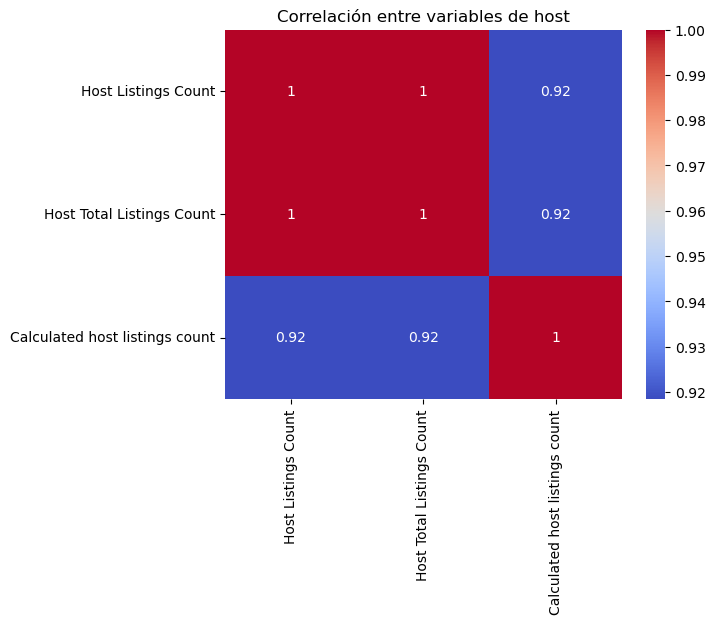

In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.heatmap(host_corr, annot=True, cmap='coolwarm')

plt.title('Correlación entre variables de host')
plt.show()

In [15]:
#Estas variables mostraban una correlación extremadamente alta (incluso 1.0 en algunos casos), 
#indicando redundancia de información. 
#Mantenerlas podría generar problemas de multicolinealidad.

house_data = house_data.drop(columns=[
    'Host Total Listings Count',
    'Calculated host listings count'
])

house_data_test = house_data_test.drop(columns=[
    'Host Total Listings Count',
    'Calculated host listings count'
])

In [16]:
house_data.dtypes

Last Scraped                     object
Host Since                       object
Host Location                    object
Host Response Time               object
Host Response Rate              float64
Host Acceptance Rate             object
Host Neighbourhood               object
Host Listings Count             float64
Host Verifications               object
Street                           object
Neighbourhood                    object
Neighbourhood Cleansed           object
Neighbourhood Group Cleansed     object
City                             object
State                            object
Zipcode                          object
Market                           object
Country Code                     object
Country                          object
Latitude                        float64
Longitude                       float64
Property Type                    object
Room Type                        object
Accommodates                      int64
Bathrooms                       float64


In [17]:
#vamos a crear una variable de precio log_price con el valor logaritmico que luego utilizaremos
import numpy as np
house_data['log_price'] = np.log1p(house_data['Price'])
house_data_test['log_price'] = np.log1p(house_data_test['Price'])

In [18]:
# Estas variables se eliminaron porque presentan un porcentaje muy alto de valores faltantes, 
# lo que dificulta su utilización y puede introducir ruido o sesgo en el modelo.
house_data.isnull().mean().sort_values(ascending=False)

Has Availability               0.999232
Host Acceptance Rate           0.997696
Monthly Price                  0.757040
Weekly Price                   0.755760
Security Deposit               0.573562
                                 ...   
Review Scores Value            0.000000
Reviews per Month              0.000000
Cancellation Policy            0.000000
Review Scores Value Missing    0.000000
Reviews per Month Missing      0.000000
Length: 61, dtype: float64

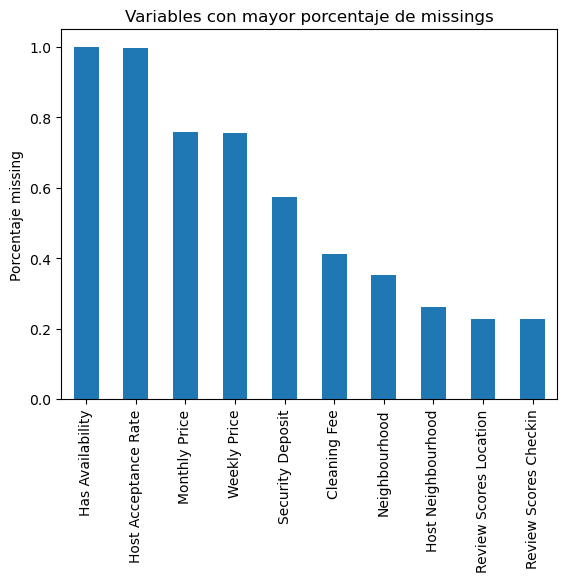

In [79]:
import matplotlib.pyplot as plt

missing_ratio = house_data.isnull().mean()

missing_ratio.sort_values(ascending=False).head(10).plot(kind='bar')

plt.title('Variables con mayor porcentaje de missings')
plt.ylabel('Porcentaje missing')
plt.show()

In [19]:
#vamos a quitar las columnas que superen 0.5 por missing

cols_to_drop = [
    'Has Availability',
    'Host Acceptance Rate',
    'Monthly Price',
    'Weekly Price'
]

house_data = house_data.drop(columns=cols_to_drop, errors='ignore')
house_data_test = house_data_test.drop(columns=cols_to_drop, errors='ignore')


Aplicamos lasso


Fitting 3 folds for each of 20 candidates, totalling 60 fits
Best CV score: -0.2823374107548562
Best params: {'model__alpha': np.float64(0.1)}


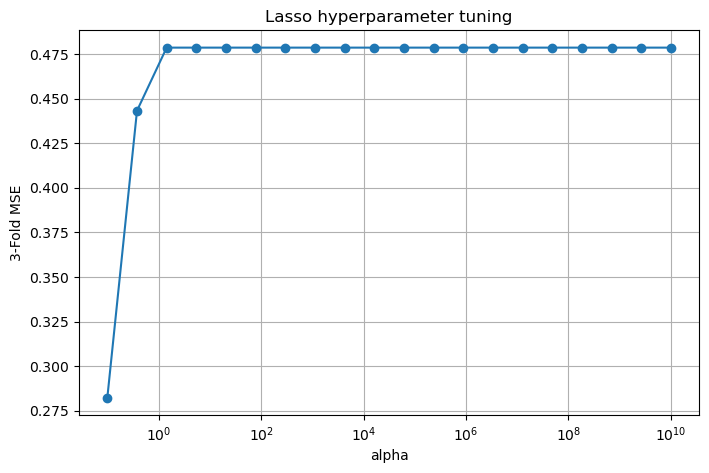


RESULTADOS LASSO
-----------------
MSE train: 0.282241868675807
MSE test : 0.29654108853578176
RMSE train: 0.5312644056172096
RMSE test : 0.5445558635583514

FEATURE IMPORTANCE (LASSO)
---------------------------
Host Response Rate 0.0
Host Listings Count 0.0
Latitude -0.0
Longitude -0.0
Accommodates 0.2881603927061503
Bathrooms 0.0
Bedrooms 0.0
Beds 0.0
Security Deposit 0.0
Cleaning Fee 0.11282756221879572
Guests Included 0.0
Extra People -0.0
Minimum Nights 0.0
Maximum Nights 0.0
Availability 30 0.0
Availability 60 0.0
Availability 90 -0.0
Availability 365 0.0
Number of Reviews -0.0
Review Scores Rating 0.0
Review Scores Accuracy 0.0
Review Scores Cleanliness 0.0
Review Scores Checkin 0.0
Review Scores Communication 0.0
Review Scores Location 0.0
Review Scores Value 0.0
Reviews per Month -0.0
Review Scores Value Missing 0.0
Reviews per Month Missing 0.0


In [20]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

#vamos a quitar los NaN de log_price
house_data = house_data[house_data['log_price'].notna()]
house_data_test = house_data_test[house_data_test['log_price'].notna()]

#tratamos los datos
y_train = house_data['log_price'].values.ravel()
y_test = house_data_test['log_price'].values.ravel()

X_train = house_data.drop(
    columns=['log_price', 'Price'],
    errors='ignore'
).select_dtypes(include=['number'])

X_test = house_data_test.drop(
    columns=['log_price', 'Price'],
    errors='ignore'
).select_dtypes(include=['number'])

#Pipeline
pipe = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler()),
    ('model', Lasso(max_iter=10000))
])

#Grid Search
alpha_vector = np.logspace(-1, 10, 20)

param_grid = {
    'model__alpha': alpha_vector
}

grid = GridSearchCV(
    estimator=pipe,
    param_grid=param_grid,
    scoring='neg_mean_squared_error',
    cv=3,
    verbose=2,
    n_jobs=2
)

grid.fit(X_train, y_train)

#Mejor modelo
best_model = grid.best_estimator_

print("Best CV score:", grid.best_score_)
print("Best params:", grid.best_params_)

#curva de validación
scores = -grid.cv_results_['mean_test_score']

plt.figure(figsize=(8,5))
plt.semilogx(alpha_vector, scores, '-o')
plt.xlabel('alpha')
plt.ylabel('3-Fold MSE')
plt.title('Lasso hyperparameter tuning')
plt.grid(True)
plt.show()

#predicción
ytrain_pred = best_model.predict(X_train)
ytest_pred = best_model.predict(X_test)

#metrica
mse_train = mean_squared_error(y_train, ytrain_pred)
mse_test = mean_squared_error(y_test, ytest_pred)

rmse_train = np.sqrt(mse_train)
rmse_test = np.sqrt(mse_test)

print('\nRESULTADOS LASSO')
print('-----------------')
print('MSE train:', mse_train)
print('MSE test :', mse_test)
print('RMSE train:', rmse_train)
print('RMSE test :', rmse_test)

#coeficientes
feature_names = X_train.columns
coefficients = best_model.named_steps['model'].coef_

print('\nFEATURE IMPORTANCE (LASSO)')
print('---------------------------')

for f, w in zip(feature_names, coefficients):
    print(f, w)

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(X_train, y_train)

ytrain_pred_rf = rf.predict(X_train)

ytest_pred_rf = rf.predict(X_test)

mse_train_rf = mean_squared_error(
    y_train,
    ytrain_pred_rf
)

mse_test_rf = mean_squared_error(
    y_test,
    ytest_pred_rf
)

rmse_train_rf = np.sqrt(mse_train_rf)

rmse_test_rf = np.sqrt(mse_test_rf)

print('\nRESULTADOS RANDOM FOREST')
print('-------------------------')

print('RMSE train:', rmse_train_rf)

print('RMSE test :', rmse_test_rf)

importance = pd.Series(
    rf.feature_importances_,
    index=X_train.columns
)

importance.sort_values(ascending=True).tail(15).plot(
    kind='barh',
    figsize=(8,6)
)

plt.title('Feature Importance - Random Forest')

plt.show()

results = pd.DataFrame({
    'Model': ['Lasso', 'Random Forest'],
    'RMSE Train': [rmse_train, rmse_train_rf],
    'RMSE Test': [rmse_test, rmse_test_rf]
})

results

In [ ]:
results.set_index('Model')[['RMSE Test']].plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Comparación modelos')

plt.ylabel('RMSE')

plt.show()

A partir de los datos obtenidos, podemos ver que Random Forest tiene un rendimiento superior al metodo lineal
Lasso para predecir el precio logarítmico de los pisos, logrando reducir el error general de predicción (RMSE)
en el conjunto de prueba. También la diferencia entre las métricas de entrenamiento y prueba em Random Forest
refleja la presencia de overfitting.
En futuras iteraciones, este comportamiento podría mitigarse mediante una optimización más exhaustiva de sus hiperparámetros (como regularizar la profundidad máxima del árbol o el número mínimo de muestras por división). Asimismo, el modelo ganaría un enorme poder predictivo si se incluyeran variables categóricas clave tras ser procesadas (como el tipo de habitación o el barrio), junto con la creación de nuevas características de negocio basadas en la estacionalidad del calendario.
